# Logistic Regression From Scratch With NumPy

This notebook builds a binary image classifier with logistic regression, written with NumPy only for the model logic. We will use the cat vs non-cat dataset in `datasets/`.

## Roadmap

1. State the problem precisely and define inputs, outputs, and success criteria.
2. Load and explore the dataset to understand shape, scale, labels, and image examples.
3. Build the core blocks: sigmoid, parameter initialization, and helper checks.
4. Orchestrate forward propagation and inspect activations, cost, and tensor shapes.
5. Orchestrate optimization with gradient descent and track learning behavior over iterations.
6. Orchestrate prediction and error analysis on train and test sets.
7. Wrap everything into a reusable `model()` function and investigate performance with plots.

At each orchestration stage, we will add checks for array shapes, parameter states, learning curves, and prediction behavior so debugging stays local and explicit.

## Step 1 - Problem Definition

We want to learn a binary classifier that predicts whether an image contains a cat.

### Input

Each example is an RGB image with shape `(num_px, num_px, 3)`. For the model, each image will later be flattened into a feature vector of size `num_px * num_px * 3`.

### Output

The label is binary:

- `1` means cat
- `0` means non-cat

### Model viewpoint

A single logistic regression unit can be written as a one-neuron neural network:

- Linear step: `z = w^T x + b`
- Activation step: `a = sigmoid(z)`
- Prediction rule: classify as cat when `a > 0.5`

### Success criteria

We want to:

- build the full training pipeline with NumPy only
- keep shapes and gradients explicit at every stage
- inspect cost and accuracy during training
- evaluate both train and test behavior to spot underfitting or overfitting

The next step is to inspect the actual dataset before deciding on preprocessing and model checks.

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

notebook_dir = Path.cwd()
if not (notebook_dir / "lr_utils.py").exists():
    notebook_dir = Path("/Users/blaiseenuh/Documents/DeepLearning_specialization/Neural Networks and Deep Learning/W2A2")
    os.chdir(notebook_dir)

from lr_utils import load_dataset

plt.rcParams["figure.figsize"] = (5, 4)
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["image.interpolation"] = "nearest"

print(f"Working directory: {Path.cwd()}")

Working directory: /Users/blaiseenuh/Documents/DeepLearning_specialization/Neural Networks and Deep Learning/W2A2


## Step 2 - Load And Inspect The Dataset

Before building the model, verify what the dataset actually contains: number of examples, image dimensions, label representation, and class names. These checks define the expected shapes for the rest of the pipeline.

In [2]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]

print(f"train_set_x shape: {train_set_x_orig.shape}")
print(f"train_set_y shape: {train_set_y.shape}")
print(f"test_set_x shape:  {test_set_x_orig.shape}")
print(f"test_set_y shape:  {test_set_y.shape}")
print(f"number of training examples: {m_train}")
print(f"number of test examples:     {m_test}")
print(f"image size: {num_px} x {num_px} x 3")
print(f"classes: {[c.decode('utf-8') for c in classes]}")

assert train_set_y.shape == (1, m_train)
assert test_set_y.shape == (1, m_test)
assert train_set_x_orig.shape[1:] == (num_px, num_px, 3)
assert test_set_x_orig.shape[1:] == (num_px, num_px, 3)

print("\nShape checks passed.")

train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape:  (50, 64, 64, 3)
test_set_y shape:  (1, 50)
number of training examples: 209
number of test examples:     50
image size: 64 x 64 x 3
classes: ['non-cat', 'cat']

Shape checks passed.


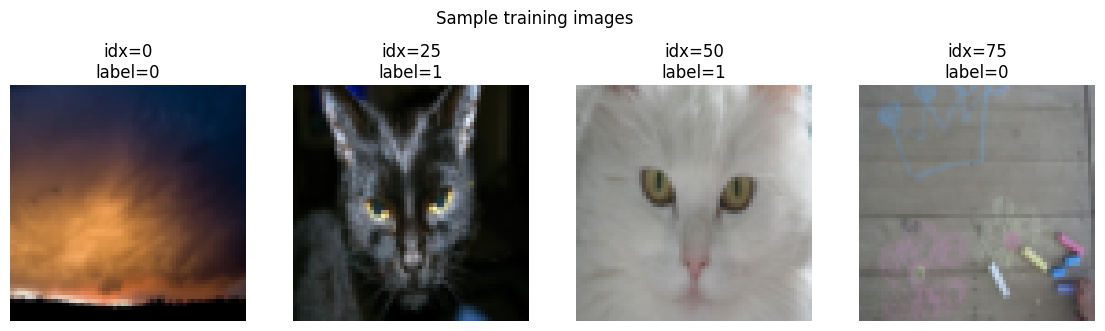

In [3]:
sample_indices = [0, 25, 50, 75]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(14, 4))
for ax, idx in zip(axes, sample_indices):
    ax.imshow(train_set_x_orig[idx])
    ax.set_title(f"idx={idx}\nlabel={train_set_y[0, idx]}")
    ax.axis("off")

plt.suptitle("Sample training images")
plt.show()



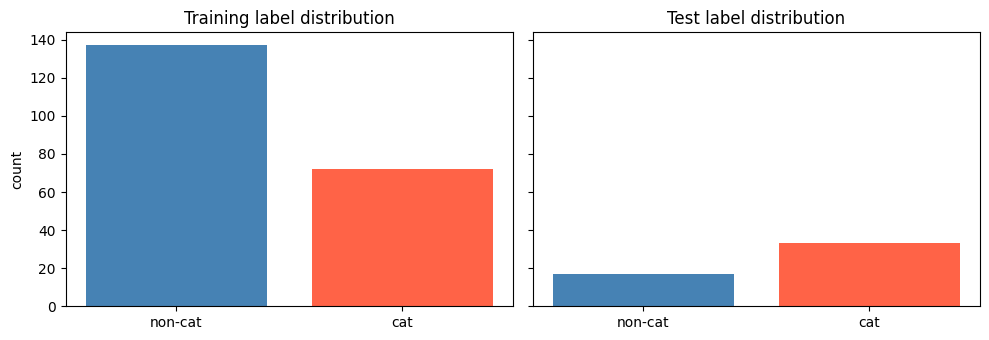

Training label distribution:
non-cat: 137 (65.55%)
cat: 72 (34.45%)

Test label distribution:
non-cat: 17 (34.00%)
cat: 33 (66.00%)


In [4]:
train_unique_labels, train_counts = np.unique(train_set_y, return_counts=True)
test_unique_labels, test_counts = np.unique(test_set_y, return_counts=True)

label_names = [classes[int(label)].decode("utf-8") for label in train_unique_labels]
train_percentages = 100 * train_counts / train_counts.sum()
test_percentages = 100 * test_counts / test_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

axes[0].bar(label_names, train_counts, color=["steelblue", "tomato"])
axes[0].set_title("Training label distribution")
axes[0].set_ylabel("count")

axes[1].bar(label_names, test_counts, color=["steelblue", "tomato"])
axes[1].set_title("Test label distribution")

plt.tight_layout()
plt.show()

print("Training label distribution:")
for name, count, pct in zip(label_names, train_counts, train_percentages):
    print(f"{name}: {count} ({pct:.2f}%)")

print("\nTest label distribution:")
for name, count, pct in zip(label_names, test_counts, test_percentages):
    print(f"{name}: {count} ({pct:.2f}%)")

## Step 3 - Preprocess The Data

Logistic regression expects each example to be a feature vector, not a 3D image tensor. We will keep preprocessing simple and explicit:

- flatten each image into a column vector
- scale pixel intensities from `[0, 255]` to `[0, 1]`
- verify the resulting shapes and value range

These checks matter because every later function will assume `X` has shape `(num_features, m)`.

In [6]:
train_set_x_flatten = train_set_x_orig.reshape(m_train, -1).T
test_set_x_flatten = test_set_x_orig.reshape(m_test, -1).T

train_set_x = train_set_x_flatten / 255.0
test_set_x = test_set_x_flatten / 255.0

print(f"train_set_x_flatten shape: {train_set_x_flatten.shape}")
print(f"test_set_x_flatten shape:  {test_set_x_flatten.shape}")
print(f"train_set_x shape:         {train_set_x.shape}")
print(f"test_set_x shape:          {test_set_x.shape}")

print(f"train pixel range: [{train_set_x.min():.3f}, {train_set_x.max():.3f}]")
print(f"test pixel range:  [{test_set_x.min():.3f}, {test_set_x.max():.3f}]")

n_x = train_set_x.shape[0]
print(f"number of input features per example: {n_x}")

assert train_set_x.shape == (num_px * num_px * 3, m_train)
assert test_set_x.shape == (num_px * num_px * 3, m_test)
assert 0.0 <= train_set_x.min() <= train_set_x.max() <= 1.0
assert 0.0 <= test_set_x.min() <= test_set_x.max() <= 1.0

print("\nPreprocessing checks passed.")

train_set_x_flatten shape: (12288, 209)
test_set_x_flatten shape:  (12288, 50)
train_set_x shape:         (12288, 209)
test_set_x shape:          (12288, 50)
train pixel range: [0.000, 1.000]
test pixel range:  [0.000, 1.000]
number of input features per example: 12288

Preprocessing checks passed.


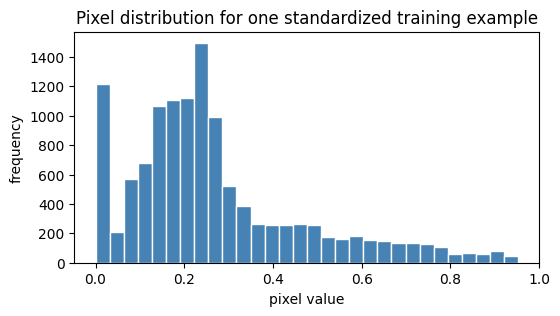

First 10 standardized features of the first training example:
[0.06666667 0.12156863 0.21960784 0.08627451 0.12941176 0.23137255
 0.09803922 0.1372549  0.24313725 0.09803922]


In [7]:
plt.figure(figsize=(6, 3))
plt.hist(train_set_x[:, 0], bins=30, color="steelblue", edgecolor="white")
plt.title("Pixel distribution for one standardized training example")
plt.xlabel("pixel value")
plt.ylabel("frequency")
plt.show()

print("First 10 standardized features of the first training example:")
print(train_set_x[:10, 0])

In [8]:
def initialize_with_zeros(dim):
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b

w, b = initialize_with_zeros(n_x)

print("Initialization sanity check:")
print("w shape:", w.shape)
print("b:", b)
print("first 5 weights:", w[:5].ravel())

assert w.shape == (n_x, 1) # Check that w has the correct shape
assert np.all(w == 0) # Check that all weights are zero
assert b == 0.0 # Check that b is zero

print("Initialization checks passed.")

Initialization sanity check:
w shape: (12288, 1)
b: 0.0
first 5 weights: [0. 0. 0. 0. 0.]
Initialization checks passed.


In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_test = np.array([-2.0, 0.0, 2.0])
a_test = sigmoid(z_test)

print("sigmoid sanity check:")
print("z:", z_test)
print("sigmoid(z):", a_test)

assert a_test.shape == z_test.shape
assert np.all((a_test > 0) & (a_test < 1))
assert np.isclose(a_test[1], 0.5)

print("Sigmoid checks passed.")

sigmoid sanity check:
z: [-2.  0.  2.]
sigmoid(z): [0.11920292 0.5        0.88079708]
Sigmoid checks passed.


In [10]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(w.T @ X + b)
    A = np.clip(A, 1e-10, 1 - 1e-10)
    cost = -np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A)) / m

    dw = (X @ (A - Y).T) / m
    db = np.sum(A - Y) / m

    grads = {"dw": dw, "db": db}
    return grads, cost

In [11]:
grads, cost = propagate(w, b, train_set_x, train_set_y)

print("Propagate sanity check:")
print(f"cost: {cost:.6f}") # Should be around 0.693147
print("dw shape:", grads["dw"].shape) # Should be (12288, 1)
print("db:", grads["db"]) # Should be a scalar
print("dw first 5 values:", grads["dw"][:5].ravel()) # ravel of first 5 values in dw.

assert grads["dw"].shape == w.shape
assert np.isscalar(grads["db"]) or np.shape(grads["db"]) == ()
assert cost > 0

print("Propagate checks passed.")

Propagate sanity check:
cost: 0.693147
dw shape: (12288, 1)
db: 0.15550239234449761
dw first 5 values: [0.04720893 0.06299841 0.04923539 0.05020171 0.06682616]
Propagate checks passed.


## Step 5 - Forward Propagation And Cost

With `w`, `b`, and `sigmoid` defined, the next simple block is the forward pass plus its gradients. For logistic regression, this function does three things:

- computes the linear score `z = w^T X + b`
- computes probabilities `A = sigmoid(z)`
- computes the cross-entropy cost and the gradients `dw` and `db`

We will keep the implementation compact and then inspect the initial cost and gradient shapes right away.

## Step 4 - Build The Simplest Core Functions

Now that `X` and `Y` are in the right shape, we can define the first two core pieces of the model:

- `sigmoid(z)`: turns a linear score into a probability in `[0, 1]`
- `initialize_with_zeros(dim)`: creates the initial weights and bias

We will keep both functions intentionally small and inspect their outputs immediately.

## Step 6 - Optimization With Gradient Descent

Now we can learn the parameters by repeatedly calling `propagate` and updating `w` and `b`. We will keep the optimizer simple:

- compute gradients and cost
- update parameters with gradient descent
- store the cost every 100 iterations
- inspect whether the cost is moving down

In [12]:
def optimize(w, b, X, Y, num_iterations=1000, learning_rate=0.005, print_cost=False):
    costs = []

    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        w = w - learning_rate * grads["dw"]
        b = b - learning_rate * grads["db"]

        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"iteration {i:4d} | cost {cost:.6f}")

    params = {"w": w, "b": b}
    return params, grads, costs

Optimization sanity check:
first recorded cost: 0.693147
last recorded cost:  0.228004
optimized w shape: (12288, 1)
optimized b: -0.015675952346772107


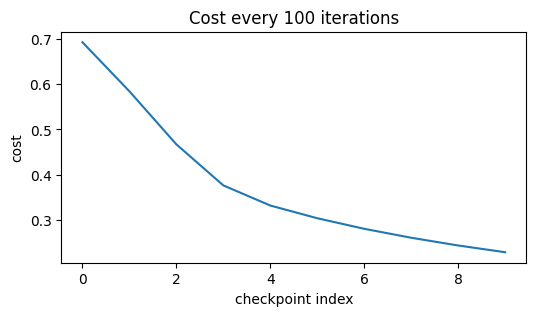

Optimization checks passed.


In [13]:
params, grads, costs = optimize(w, b, train_set_x, train_set_y, num_iterations=1000, learning_rate=0.005)

print("Optimization sanity check:")
print(f"first recorded cost: {costs[0]:.6f}")
print(f"last recorded cost:  {costs[-1]:.6f}")
print("optimized w shape:", params["w"].shape)
print("optimized b:", params["b"])

assert params["w"].shape == w.shape
assert len(costs) == 10
assert costs[-1] < costs[0]

plt.figure(figsize=(6, 3))
plt.plot(costs)
plt.title("Cost every 100 iterations")
plt.xlabel("checkpoint index")
plt.ylabel("cost")
plt.show()

print("Optimization checks passed.")

## Step 7 - Prediction

Once the parameters are learned, prediction should stay minimal: compute probabilities with the learned `w` and `b`, then threshold them at `0.5`.

In [14]:
def predict(w, b, X):
    A = sigmoid(w.T @ X + b)
    Y_prediction = (A > 0.5).astype(int)
    return Y_prediction

In [15]:
train_pred_preview = predict(params["w"], params["b"], train_set_x)

print("Prediction sanity check:")
print("prediction shape:", train_pred_preview.shape)
print("first 10 predictions:", train_pred_preview[:, :10])
print("first 10 labels:     ", train_set_y[:, :10])

assert train_pred_preview.shape == train_set_y.shape

print("Prediction checks passed.")

Prediction sanity check:
prediction shape: (1, 209)
first 10 predictions: [[0 0 1 0 0 0 0 1 0 0]]
first 10 labels:      [[0 0 1 0 0 0 0 1 0 0]]
Prediction checks passed.


## Step 8 - Bring Everything Together In A Model

The final wrapper should be small: initialize, optimize, predict, and report train/test accuracy.

In [16]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.005, print_cost=False):
    w, b = initialize_with_zeros(X_train.shape[0])
    params, grads, costs = optimize(
        w, b, X_train, Y_train,
        num_iterations=num_iterations,
        learning_rate=learning_rate,
        print_cost=print_cost,
    )

    Y_prediction_train = predict(params["w"], params["b"], X_train)
    Y_prediction_test = predict(params["w"], params["b"], X_test)

    train_accuracy = 100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
    test_accuracy = 100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100

    results = {
        "costs": costs,
        "Y_prediction_train": Y_prediction_train,
        "Y_prediction_test": Y_prediction_test,
        "w": params["w"],
        "b": params["b"],
        "learning_rate": learning_rate,
        "num_iterations": num_iterations,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
    }
    return results

iteration    0 | cost 0.693147
iteration  100 | cost 0.584508
iteration  200 | cost 0.466949
iteration  300 | cost 0.376007
iteration  400 | cost 0.331463
iteration  500 | cost 0.303273
iteration  600 | cost 0.279880
iteration  700 | cost 0.260042
iteration  800 | cost 0.242941
iteration  900 | cost 0.228004
iteration 1000 | cost 0.214820
iteration 1100 | cost 0.203078
iteration 1200 | cost 0.192544
iteration 1300 | cost 0.183033
iteration 1400 | cost 0.174399
iteration 1500 | cost 0.166521
iteration 1600 | cost 0.159305
iteration 1700 | cost 0.152667
iteration 1800 | cost 0.146542
iteration 1900 | cost 0.140872

Final model metrics:
train accuracy: 99.04%
test accuracy:  70.00%


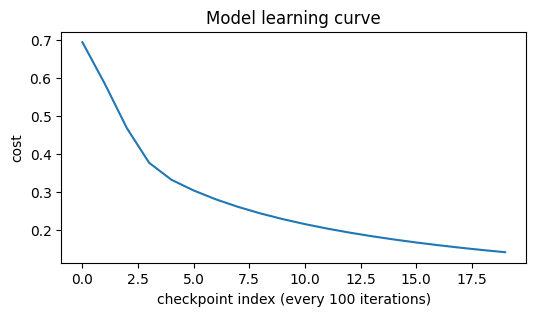

In [17]:
results = model(
    train_set_x, train_set_y,
    test_set_x, test_set_y,
    num_iterations=2000,
    learning_rate=0.005,
    print_cost=True,
)

print("\nFinal model metrics:")
print(f"train accuracy: {results['train_accuracy']:.2f}%")
print(f"test accuracy:  {results['test_accuracy']:.2f}%")

plt.figure(figsize=(6, 3))
plt.plot(results["costs"])
plt.title("Model learning curve")
plt.xlabel("checkpoint index (every 100 iterations)")
plt.ylabel("cost")
plt.show()

number of misclassified test examples: 15


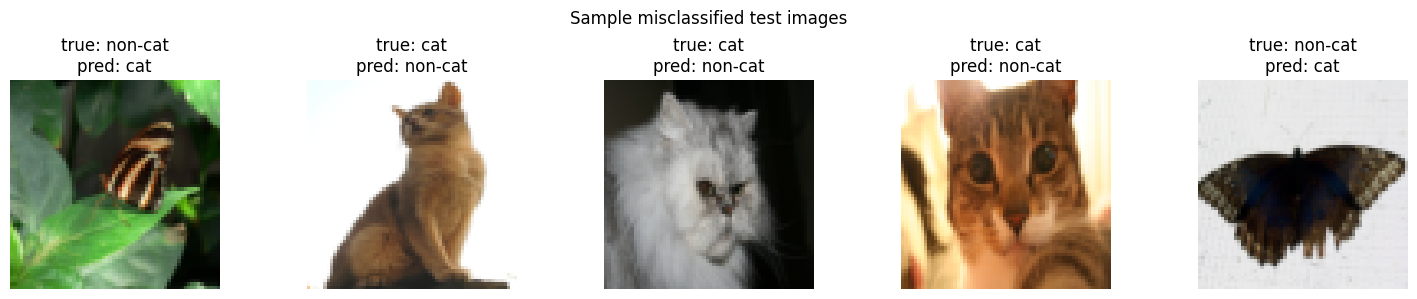

In [18]:
misclassified = np.where(results["Y_prediction_test"] != test_set_y)[1]
print(f"number of misclassified test examples: {len(misclassified)}")

if len(misclassified) > 0:
    show_n = min(5, len(misclassified))
    fig, axes = plt.subplots(1, show_n, figsize=(15, 3))
    if show_n == 1:
        axes = [axes]

    for ax, idx in zip(axes, misclassified[:show_n]):
        ax.imshow(test_set_x_orig[idx])
        true_label = classes[int(test_set_y[0, idx])].decode("utf-8")
        pred_label = classes[int(results["Y_prediction_test"][0, idx])].decode("utf-8")
        ax.set_title(f"true: {true_label}\npred: {pred_label}")
        ax.axis("off")

    plt.suptitle("Sample misclassified test images")
    plt.tight_layout()
    plt.show()

### Probability Histograms

A useful substitute for a direct boundary plot is to compare the predicted probabilities for each class. If the model separates the classes well, the distributions of

$$P(y = 1 \mid x) = \sigma(w^T x + b)$$

should pull apart.

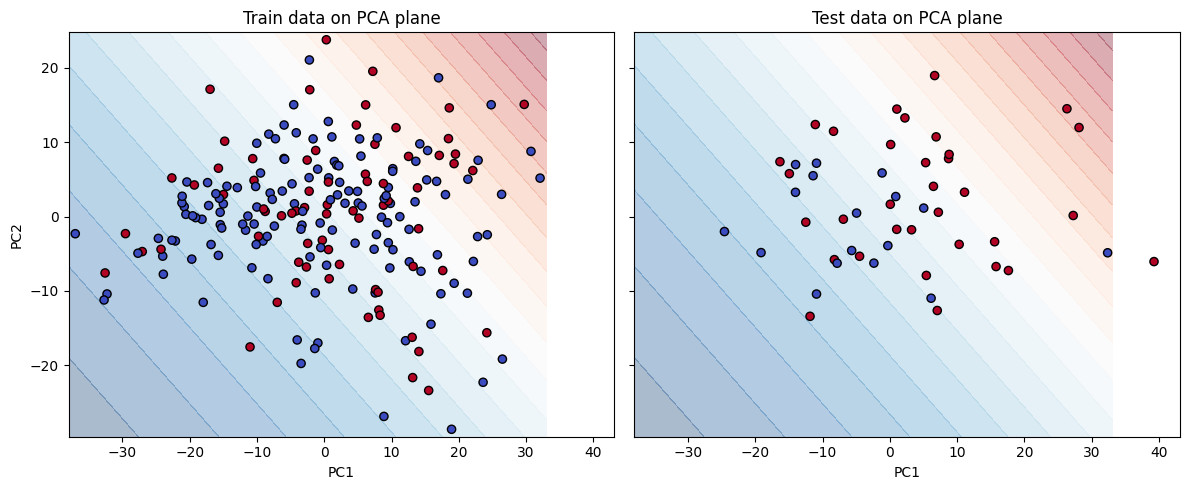

In [21]:
train_matrix = train_set_x.T
test_matrix = test_set_x.T

mean_vector = train_matrix.mean(axis=0, keepdims=True)
train_centered = train_matrix - mean_vector
test_centered = test_matrix - mean_vector

_, _, Vt = np.linalg.svd(train_centered, full_matrices=False)
pca_components = Vt[:2]

train_pca = train_centered @ pca_components.T
test_pca = test_centered @ pca_components.T

x_min, x_max = train_pca[:, 0].min() - 1.0, train_pca[:, 0].max() + 1.0
y_min, y_max = train_pca[:, 1].min() - 1.0, train_pca[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_reconstructed = mean_vector + grid_pca @ pca_components
grid_scores = grid_reconstructed @ results["w"] + results["b"]
grid_probs = sigmoid(grid_scores).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].contourf(xx, yy, grid_probs, levels=20, cmap="RdBu_r", alpha=0.35)
axes[0].contour(xx, yy, grid_probs, levels=[0.5], colors="black", linewidths=2)
scatter0 = axes[0].scatter(train_pca[:, 0], train_pca[:, 1], c=train_set_y.ravel(), cmap="coolwarm", edgecolors="k", s=35)
axes[0].set_title("Train data on PCA plane")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].contourf(xx, yy, grid_probs, levels=20, cmap="RdBu_r", alpha=0.35)
axes[1].contour(xx, yy, grid_probs, levels=[0.5], colors="black", linewidths=2)
axes[1].scatter(test_pca[:, 0], test_pca[:, 1], c=test_set_y.ravel(), cmap="coolwarm", edgecolors="k", s=35)
axes[1].set_title("Test data on PCA plane")
axes[1].set_xlabel("PC1")

plt.tight_layout()
plt.show()

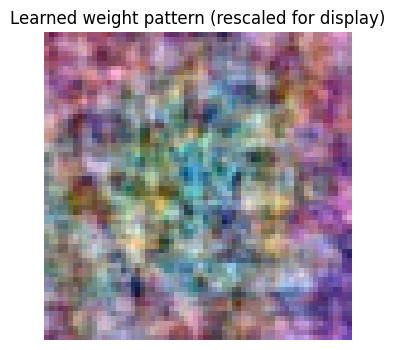

weight min: -0.062487
weight max: 0.057760
weight mean: 0.000053


In [20]:
weight_image = results["w"].reshape(num_px, num_px, 3)

plt.figure(figsize=(4, 4))
plt.imshow((weight_image - weight_image.min()) / (weight_image.max() - weight_image.min()))
plt.title("Learned weight pattern (rescaled for display)")
plt.axis("off")
plt.show()

print(f"weight min: {results['w'].min():.6f}")
print(f"weight max: {results['w'].max():.6f}")
print(f"weight mean: {results['w'].mean():.6f}")

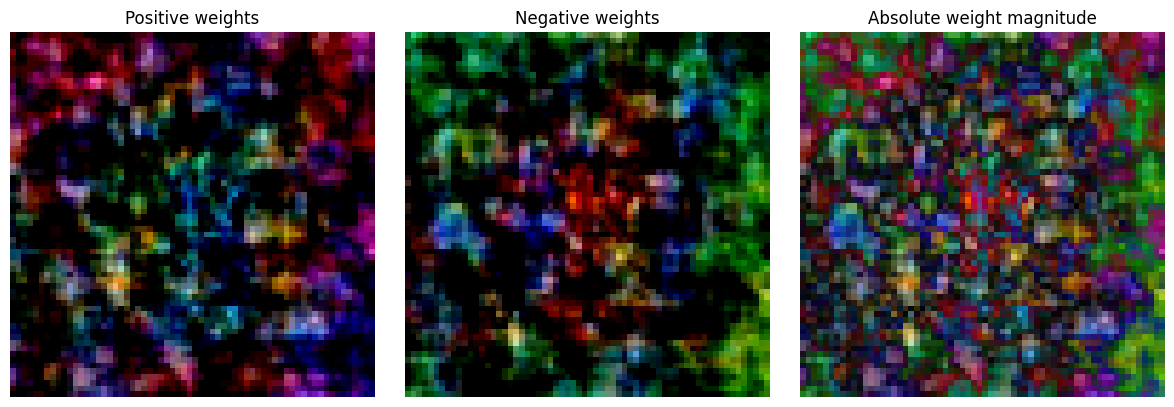

positive weight mass: 84.269441
negative weight mass: 83.623668
max absolute weight:  0.062487


In [ ]:
"""
What not to over-interpret:

Do not treat these colors as actual cat-image parts.
Do not assume a bright patch means “this is a cat ear.”
In this model, the weights are best understood as a sensitivity map, not an object-part map.

"""


positive_map = np.maximum(weight_image, 0)
negative_map = np.maximum(-weight_image, 0)
absolute_map = np.abs(weight_image)

def rescale_for_display(image):
    image_min = image.min()
    image_max = image.max()
    if image_max == image_min:
        return np.zeros_like(image)
    return (image - image_min) / (image_max - image_min)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(rescale_for_display(positive_map))
axes[0].set_title("Positive weights")
axes[0].axis("off")

axes[1].imshow(rescale_for_display(negative_map))
axes[1].set_title("Negative weights")
axes[1].axis("off")

axes[2].imshow(rescale_for_display(absolute_map))
axes[2].set_title("Absolute weight magnitude")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"positive weight mass: {positive_map.sum():.6f}")
print(f"negative weight mass: {negative_map.sum():.6f}")
print(f"max absolute weight:  {absolute_map.max():.6f}")

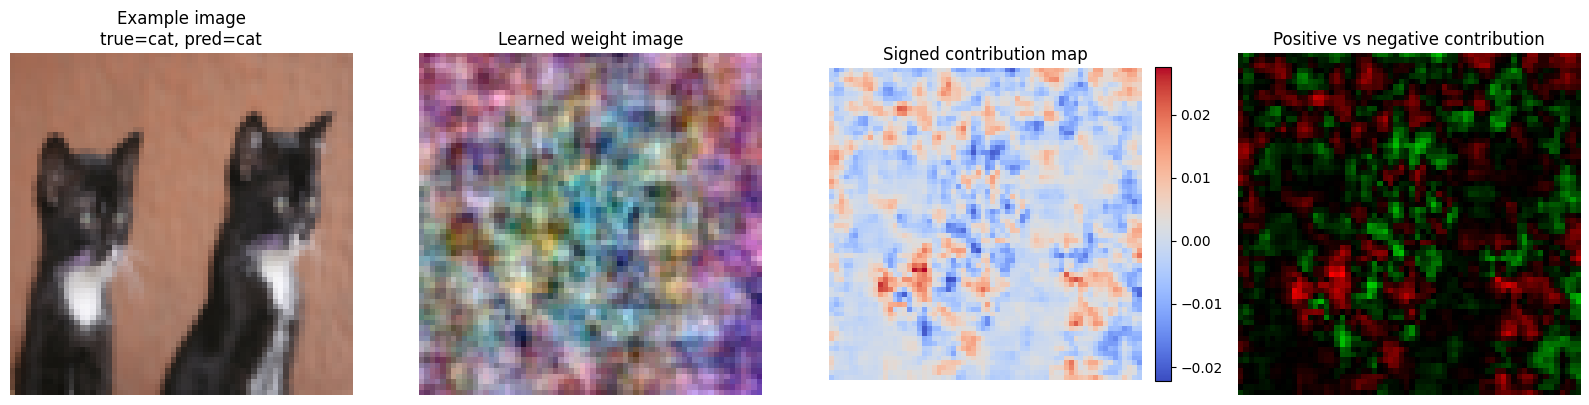

example index: 0
linear score z: 2.818547
predicted probability of cat: 0.943670
sum of pixel contributions: 2.834453
bias term: -0.015906
contributions + bias: 2.818547


In [28]:
example_idx = 0
example_image = test_set_x_orig[example_idx]
example_vector = test_set_x[:, example_idx:example_idx + 1]
example_contribution = (results["w"] * example_vector).reshape(num_px, num_px, 3)

example_true = classes[int(test_set_y[0, example_idx])].decode("utf-8")
example_pred = classes[int(results["Y_prediction_test"][0, example_idx])].decode("utf-8")
example_score = (results["w"].T @ example_vector + results["b"]).item()
example_prob = sigmoid(np.array([[example_score]])).item()

signed_contribution_2d = example_contribution.mean(axis=2)
positive_contribution = np.maximum(signed_contribution_2d, 0)
negative_contribution = np.maximum(-signed_contribution_2d, 0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(example_image)
axes[0].set_title(f"Example image\ntrue={example_true}, pred={example_pred}")
axes[0].axis("off")

axes[1].imshow(rescale_for_display(weight_image))
axes[1].set_title("Learned weight image")
axes[1].axis("off")

im2 = axes[2].imshow(signed_contribution_2d, cmap="coolwarm")
axes[2].set_title("Signed contribution map")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].imshow(rescale_for_display(np.stack([positive_contribution, negative_contribution, np.zeros_like(positive_contribution)], axis=2)))
axes[3].set_title("Positive vs negative contribution")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print(f"example index: {example_idx}")
print(f"linear score z: {example_score:.6f}")
print(f"predicted probability of cat: {example_prob:.6f}")
print(f"sum of pixel contributions: {example_contribution.sum():.6f}")
print(f"bias term: {results['b']:.6f}")
print(f"contributions + bias: {example_contribution.sum() + results['b']:.6f}")

### Aligning One Image With The Learned Weights

To see how the model reads one конкретe example, compare the image with the learned weights at the same pixel locations.

For one image $x$, the model score is

$$z = w^T x + b = \sum_j w_j x_j + b$$

So the quantity

$$c_j = w_j x_j$$

is the contribution of feature $j$ to the score before summing across all features. After reshaping back to image form, the contribution map shows where that specific image is pushing the classifier toward or away from the cat class.

### Positive, Negative, And Absolute Weight Maps

The learned weight image becomes easier to interpret if we separate three views:

- positive weights: pixels that push the score $z = w^T x + b$ upward, which increases $P(y=1 \mid x)$
- negative weights: pixels that push the score downward, which decreases $P(y=1 \mid x)$
- absolute weights: pixels with the largest influence regardless of direction

Formally, if $W_{image}$ is the reshaped weight tensor, then

$$W_{+} = \max(W_{image}, 0), \qquad W_{-} = \max(-W_{image}, 0), \qquad W_{abs} = |W_{image}|$$

This split helps distinguish direction from magnitude.

### A 2D PCA View Of The Model

The true boundary lives in a high-dimensional image space, so we project the data onto two principal directions for visualization. If the centered input matrix is $X_c$, PCA finds orthogonal directions of largest variance. Here we use the first two right singular vectors from the SVD of the centered training data.

For a 2D PCA coordinate $u$, we build an approximate image-space point on that PCA plane and evaluate the original model there:

$$x_{approx} = \mu + U_2^T u$$

Then we plot the contour where the model is undecided:

$$w^T x_{approx} + b = 0$$

This is not the full boundary in the original space. It is a slice of the model behavior on the 2D PCA plane.

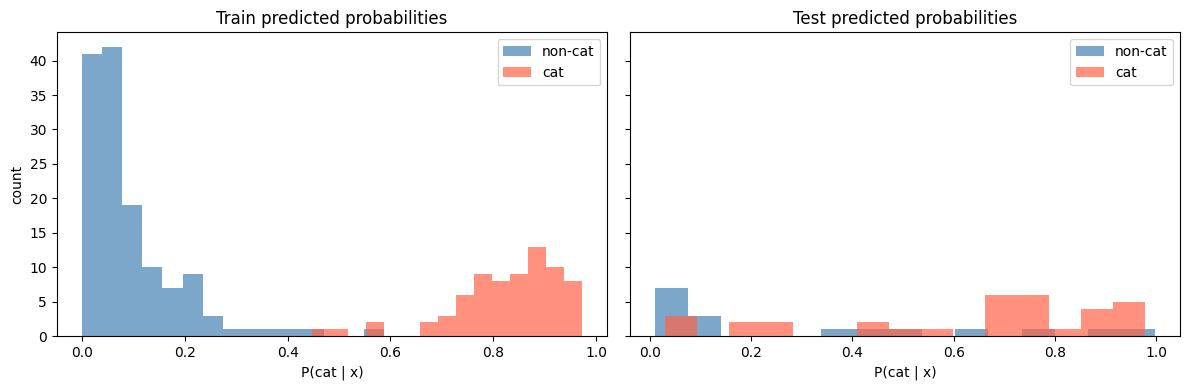

mean train probability for cat images:     0.827
mean train probability for non-cat images: 0.091
mean test probability for cat images:      0.625
mean test probability for non-cat images:  0.306


In [26]:
train_probs = sigmoid(results["w"].T @ train_set_x + results["b"]).ravel()
test_probs = sigmoid(results["w"].T @ test_set_x + results["b"]).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(train_probs[train_set_y.ravel() == 0], bins=15, alpha=0.7, label="non-cat", color="steelblue")
axes[0].hist(train_probs[train_set_y.ravel() == 1], bins=15, alpha=0.7, label="cat", color="tomato")
axes[0].set_title("Train predicted probabilities")
axes[0].set_xlabel("P(cat | x)")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].hist(test_probs[test_set_y.ravel() == 0], bins=15, alpha=0.7, label="non-cat", color="steelblue")
axes[1].hist(test_probs[test_set_y.ravel() == 1], bins=15, alpha=0.7, label="cat", color="tomato")
axes[1].set_title("Test predicted probabilities")
axes[1].set_xlabel("P(cat | x)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"mean train probability for cat images:     {train_probs[train_set_y.ravel() == 1].mean():.3f}")
print(f"mean train probability for non-cat images: {train_probs[train_set_y.ravel() == 0].mean():.3f}")
print(f"mean test probability for cat images:      {test_probs[test_set_y.ravel() == 1].mean():.3f}")
print(f"mean test probability for non-cat images:  {test_probs[test_set_y.ravel() == 0].mean():.3f}")

### Visualizing The Weight Vector

Each feature in `w` corresponds to one pixel channel in the image. After training, we can reshape the learned vector back into image form:

$$w \in \mathbb{R}^{n_x \times 1} \rightarrow W_{image} \in \mathbb{R}^{num\_px \times num\_px \times 3}$$

This does not show a sample image. It shows which pixel patterns increase or decrease the score $z = w^T x + b$.

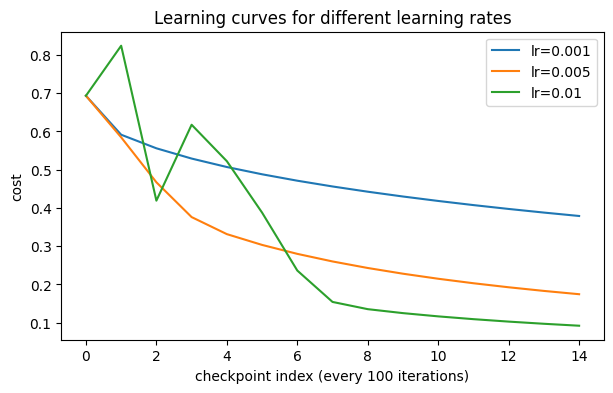

Accuracy by learning rate:
lr=0.001: train=89.00% |  test=64.00%
lr=0.005: train=97.61% |  test=70.00%
lr=0.01: train=99.52% |  test=68.00%


In [23]:
learning_rates = [0.001, 0.005, 0.01]
models_by_lr = {}

plt.figure(figsize=(7, 4))
for lr in learning_rates:
    lr_results = model(
        train_set_x, train_set_y,
        test_set_x, test_set_y,
        num_iterations=1500,
        learning_rate=lr,
        print_cost=False,
    )
    models_by_lr[lr] = lr_results
    plt.plot(lr_results["costs"], label=f"lr={lr}")

plt.title("Learning curves for different learning rates")
plt.xlabel("checkpoint index (every 100 iterations)")
plt.ylabel("cost")
plt.legend()
plt.show()

print("Accuracy by learning rate:")
for lr, lr_results in models_by_lr.items():
    print(
        f"lr={lr}: train={lr_results['train_accuracy']:.2f}% | ",
        f"test={lr_results['test_accuracy']:.2f}%"
    )

### Comparing Learning Rates

Gradient descent updates the parameters as

$$w := w - \alpha \, dw, \qquad b := b - \alpha \, db$$

where $\alpha$ is the learning rate. A small learning rate may converge slowly, while a large one may move too aggressively. Comparing learning curves for several values of $\alpha$ is a direct way to study optimization behavior.

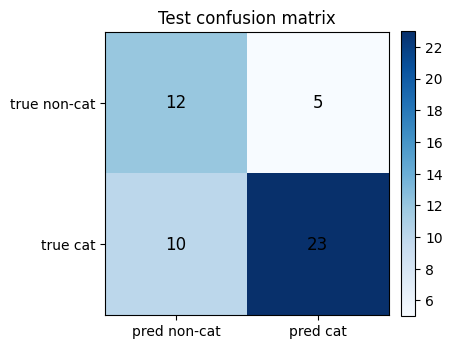

TN: 12, FP: 5, FN: 10, TP: 23
precision: 0.821
recall:    0.697


In [22]:
y_true = test_set_y.ravel()
y_pred = results["Y_prediction_test"].ravel()

tn = np.sum((y_true == 0) & (y_pred == 0))
fp = np.sum((y_true == 0) & (y_pred == 1))
fn = np.sum((y_true == 1) & (y_pred == 0))
tp = np.sum((y_true == 1) & (y_pred == 1))

conf_matrix = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(4, 4))
plt.imshow(conf_matrix, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="black", fontsize=12)
plt.xticks([0, 1], ["pred non-cat", "pred cat"])
plt.yticks([0, 1], ["true non-cat", "true cat"])
plt.title("Test confusion matrix")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(f"precision: {precision:.3f}")
print(f"recall:    {recall:.3f}")

### Test Confusion Matrix

A confusion matrix shows how predictions break down by class. For binary classification, the four entries are:

- true negative: predicted non-cat, actual non-cat
- false positive: predicted cat, actual non-cat
- false negative: predicted non-cat, actual cat
- true positive: predicted cat, actual cat

This complements accuracy because it shows which type of error the model makes more often.

### Interpreting The Probability Histograms

The histogram view is useful because the model's decision rule is just thresholding the probability at `0.5`. In symbols,

$$\hat{y} = \mathbb{1}[\sigma(w^T x + b) > 0.5]$$

A stronger model pushes cat images toward probabilities near `1` and non-cat images toward probabilities near `0`. Overlap between the two distributions means the classifier is uncertain on some region of the input space.

In this notebook, the train distributions separate more cleanly than the test distributions. That is a compact way to see that generalization is weaker than training performance.